In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/engineered_data.csv")

In [6]:
features = [
    "credit_limit",
    "num_cards_issued",
    "account_age",
    "pin_age",
    "has_chip",
    "card_type",
    "card_on_dark_web",
    "card_brand_encoded"
]

X = df[features]

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [11]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

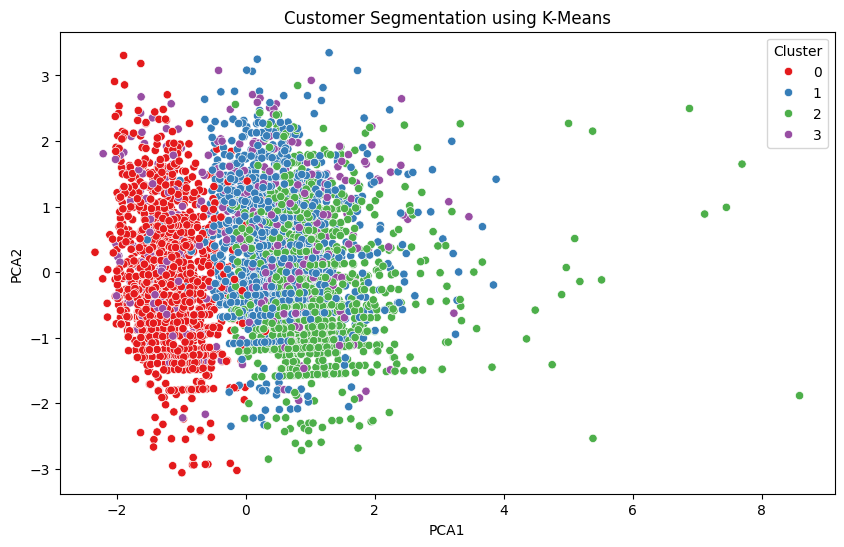

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set1"
)

plt.title("Customer Segmentation using K-Means")
plt.show()

In [14]:
df["Cluster"].value_counts()

Cluster
0    1461
2    1207
1    1194
3     452
Name: count, dtype: int64

In [15]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df["Cluster"])

print("Silhouette Score:", score)

Silhouette Score: 0.20416561958639146


In [16]:
df["Cluster"].value_counts()

Cluster
0    1461
2    1207
1    1194
3     452
Name: count, dtype: int64

In [17]:
cluster_summary = df.groupby("Cluster").agg({
    "credit_limit":"mean",
    "num_cards_issued":"mean",
    "account_age":"mean",
    "pin_age":"mean",
    "has_chip":"mean",
    "card_type":"mean",
    "card_on_dark_web":"mean"
})

cluster_summary

,credit_limit,num_cards_issued,account_age,pin_age,has_chip,card_type,card_on_dark_web
Cluster,,,,,,,
0,8067.162218,1.514716,14.993840,7.838467,1.000000,1.000000,0.0
1,16759.567002,2.017588,15.268007,7.994137,1.000000,0.009213,0.0
2,20793.791218,1.004971,14.458989,7.867440,0.999171,0.003314,0.0
3,14200.752212,1.475664,14.942478,8.305310,0.000000,0.382743,0.0
